<a href="https://colab.research.google.com/github/agroimpacts/adleo/blob/main/assignments/assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 - Fine-tuning and Inference (prediction)

## Instructions

Please follow the [instructions](assignments-setup.qmd) for setting up, completing, and submitting your assignments.

## Assignment Overview

The focus of this assignment is on model deployment, fine-tuning, and evaluation using the models you developed in Assignment 2.

In Assignment 2, you built complete training pipelines for both image classification and semantic segmentation tasks. In this assignment, you will move beyond model construction and focus on:

- Performing inference with trained models

- Applying fine-tuning strategies

- Evaluating model performance using appropriate metrics

- Interpreting segmentation outputs quantitatively

After completing this assignment, you will understand how to:

- Transition from training mode to inference mode correctly in PyTorch

- Apply transfer learning and fine-tuning strategies

- Compute and interpret evaluation metrics for semantic segmentation

- Compare model performance using quantitative measures

This assignment emphasizes model evaluation and performance analysis, which are essential components of any real-world deep learning workflow.

**Note:** To perform the analyses here, as with Assignment 2, you will need to have either a locally capable GPU or have a Colab Pro subscription.  

## Assignment

Follow the instructions below to complete your coding assignment.

Run the code in the sections beginning with "Static" unchanged, unless otherwise indicated.

### Static code 1

In [1]:
# @title Mount drive and run imports
#Vs code loal

In [2]:
# @title Importing Necessary Packages

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import torch.nn.functional as F


import torchvision.transforms as transforms
from torchvision.transforms import v2
import torchvision.datasets as datasets
import torch.utils.data as data
import copy

import matplotlib.pyplot as plt
import cv2
import numpy as np
import random
import numbers

import pandas as pd
import os

from pathlib import Path

from torch.utils.data import Dataset, DataLoader
import rasterio

# function to ensure reproducibility by fixing random state
def set_seed(seed_value):
    """Set seed for reproducibility."""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(1)

### Task 1

#### **Run inference on your trained MNIST ResNet18 model (no training in this assignment) (steps 1.1-1.3)**

In this task, you will evaluate the ResNet18 model you trained and saved in Assignment 2.

Switch the model to evaluation mode using `model.eval()` and run inference using `torch.no_grad()` against the model test split.

Compute and print the overall accuracy.


#### Step 1.1: Load the MNIST test dataset and Rebuild the ResNet18


- Load the MNIST test dataset only and create a `test_loader` (you've learned this part in the first assignment).


- Rebuild the same ResNet18 architecture used in Assignment 2 (you'de learned this part in the second assignment):

  - Modify the first convolution layer to accept 1-channel MNIST images.

  - Modify the final fully connected layer to output 10 classes.

In [22]:
# @title Save path

## Modify to the path as needed in your pipeline
save_dir = "/Users/gabrielcustodioguzman/Desktop/Adleo/mnist_data/MNIST"

model_dir = "/Users/gabrielcustodioguzman/Desktop/Adleo"

In [23]:
# MNIST test transforms
test_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5,), (0.5,))
])

# Load MNIST test dataset
test_dataset = datasets.MNIST(
    root=save_dir,
    train=False,
    download=False,
    transform=test_transforms
)

# Test loader
test_loader = DataLoader(
    test_dataset,
    batch_size=50,
    shuffle=False
)

# Rebuild ResNet18
model = models.resnet18(weights=None)

# Change first conv layer for grayscale MNIST
model.conv1 = nn.Conv2d(
    1,
    64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

# Change output layer to 10 classes
model.fc = nn.Linear(model.fc.in_features, 10)

print(model)


ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [24]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

num_classes = 10

print("Criterion, optimizer, and model setup complete.")

Criterion, optimizer, and model setup complete.


#### Step 1.2: Load the Saved Model Weights

In Assignment 2, you saved your trained model parameters using `torch.save(model.state_dict(), ...)`.

To reuse those learned parameters, you must now:

- Load the saved `.pth` file.

- Move the model to the appropriate device (CPU or GPU).

Example:

>```python
>device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
>model = model.to(device)
>```

- Use `model.load_state_dict(torch.load(...))` to load the parameters.


Notes:
- The architecture must match exactly the one used during training.
- If layers differ, loading will fail.
- Do not reinitialize the model after loading the weights.
- After completing this step, your model should be ready for inference.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

model.load_state_dict(
    torch.load(
        "/Users/gabrielcustodioguzman/Desktop/Adleo/resnet18_mnist.pth",
        map_location=device
    )
)

model.eval()

print("Model weights loaded successfully!")
print("Using device:", device)


Model weights loaded successfully!
Using device: cpu


#### Step 1.3: Running inference

- You must run inference on the entire test set, not only one batch.
- Switch the model to inference behavior using: `model.eval()`
- Disable gradient tracking using: `with torch.no_grad():`

- For each batch:
    - Run forward pass: `logits = model(images)`
    - Convert logits to predicted class IDs using: `preds = torch.argmax(logits, dim=1)`
    - Accumulate the number of correct predictions and total samples
    - Compute and print final test accuracy:
        - Example:

        ```python
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        test_acc = correct / total
        print(f"Test accuracy: {test_acc:.4f}")
        ```

In [26]:
correct = 0
total = 0

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")





Test Accuracy: 98.79%


### Task 2

#### **Fine-tune and evaluate your segmentation model from Assignment 2 (steps 2.1–2.5)**

In this task, you will reuse the segmentation model that you implemented and trained in Assignment 2. You will first apply a fine-tuning strategy, then evaluate the model using proper segmentation metrics.

Compile the static code below for use in the subsequent tasks.

### Static code 2

In [8]:
#@title Input normalization
def min_max_normalize_image(image, dtype=np.float32):
    """
    image_path(str) -- Absolute path to the image patch.
    dtype (numpy datatype) -- data type of the normalized image default is
    "np.float32".
    """

    # Calculate the minimum and maximum values for each band
    min_values = np.nanmin(image, axis=(1, 2))[:, np.newaxis, np.newaxis]
    max_values = np.nanmax(image, axis=(1, 2))[:, np.newaxis, np.newaxis]

    # Normalize the image data to the range [0, 1]
    normalized_img = (image - min_values) / (max_values - min_values)
    # normalized_img = normalized_img.astype(dtype)

    # Return the normalized image data
    return normalized_img

In [9]:
#@title Rotation transformation (`cv2`)
def rotate_image_and_label(image, label, angle):
    """
    Applies rotation augmentation to an image patch and label.

    Args:
        image (numpy array) : The input image patch as a numpy array.
        label (numpy array) : The corresponding label as a numpy array.
        angle (lost of floats) : If the list has exactly two elements they will
            be considered the lower and upper bounds for the rotation angle
            (in degrees) respectively. If number of elements are bigger than 2,
            then one value is chosen randomly as the roatation angle.

    Returns:
        A tuple containing the rotated image patch and label as numpy arrays.
    """
    if isinstance(angle, tuple) or isinstance(angle, list):
        if len(angle) == 2:
            rotation_degree = random.uniform(angle[0], angle[1])
        elif len(angle) > 2:
            rotation_degree = random.choice(angle)
        else:
            raise ValueError("Parameter degree needs at least two elements.")
    else:
        raise ValueError(
            "Rotation bound param for augmentation must be a tuple or list."
        )

    # Define the center of the image patch
    center = tuple(np.array(label.shape)/2.0)

    # Define the rotation matrix
    rotation_matrix = cv2.getRotationMatrix2D(center, rotation_degree, 1.0)

    # Apply rotation augmentation to the image patch
    rotated_image = cv2.warpAffine(image, rotation_matrix, image.shape[:2],
                                   flags=cv2.INTER_LINEAR)

    # Apply rotation augmentation to the label
    rotated_label = cv2.warpAffine(label, rotation_matrix, label.shape[:2],
                                   flags=cv2.INTER_NEAREST)

    # Return the rotated image patch and label as a tuple
    return rotated_image.copy(), np.rint(rotated_label.copy())

In [10]:
#@title Image flipping (`cv2`)
def flip_image_and_label(image, label, flip_type):
    """
    Applies horizontal or vertical flip augmentation to an image patch and label

    Args:
        image (numpy array) : The input image patch as a numpy array.
        label (numpy array) : The corresponding label as a numpy array.
        flip_type (string) : Based on the direction of flip. Can be either
            'hflip' or 'vflip'.

    Returns:
        A tuple containing the flipped image patch and label as numpy arrays.
    """
    if flip_type == 'hflip':
        # Apply horizontal flip augmentation to the image patch
        flipped_image = cv2.flip(image, 1)

        # Apply horizontal flip augmentation to the label
        flipped_label = cv2.flip(label, 1)

    elif flip_type == 'vflip':
        # Apply vertical flip augmentation to the image patch
        flipped_image = cv2.flip(image, 0)

        # Apply vertical flip augmentation to the label
        flipped_label = cv2.flip(label, 0)

    else:
        raise ValueError("Flip direction must be 'horizontal' or 'vertical'.")

    # Return the flipped image patch and label as a tuple
    return flipped_image.copy(), flipped_label.copy()

In [11]:
class Evaluator(object):
    def __init__(self, num_class):
        self.num_class = num_class
        self.confusion_matrix = np.zeros((self.num_class,)*2)

    def Pixel_Accuracy(self):
        # Overall Pixel Accuracy
        Acc = np.diag(self.confusion_matrix).sum() / self.confusion_matrix.sum()
        return Acc

    def Mean_Intersection_over_Union(self):
        # Mean IoU
        MIoU = np.diag(self.confusion_matrix) / (
            np.sum(self.confusion_matrix, axis=1) +
            np.sum(self.confusion_matrix, axis=0) -
            np.diag(self.confusion_matrix)
        )
        MIoU = np.nanmean(MIoU)
        return MIoU

    def _generate_matrix(self, gt_image, pre_image):
        mask = (gt_image >= 0) & (gt_image < self.num_class)
        label = self.num_class * gt_image[mask].astype('int') + pre_image[mask]
        count = np.bincount(label, minlength=self.num_class**2)
        confusion_matrix = count.reshape(self.num_class, self.num_class)
        return confusion_matrix

    def add_batch(self, gt_image, pre_image):
        assert gt_image.shape == pre_image.shape
        self.confusion_matrix += self._generate_matrix(gt_image, pre_image)

    def reset(self):
        self.confusion_matrix = np.zeros((self.num_class,) * 2)

#### Step 2.1: Load Finetuning and test dataset

Please copy paste your `ActiveLoadingDataset` class here. You will need to make 2 critical changes to be able to read test data correctly for prediction:

1. Allow "test" as a valid split by modifying the assertion in `__init__` to:

    ```python
    assert self.split in ["train", "validate", "test"], "Split is not recognized."
    ```

2. Return the image file path from `__getitem__` (as a string) so predictions can be saved with correct geolocation metadata:

    ```python
    return image_tensor, label_tensor, str(img_path)
    ```

In [27]:
src_dir = "/Users/gabrielcustodioguzman/Desktop/Adleo/mappingafrica-256"

csv_path = "/Users/gabrielcustodioguzman/Desktop/Adleo/mappingafrica-256/splits.csv"

In [28]:
class ActiveLoadingDataset(Dataset):

    def __init__(self, src_dir, csv_path, split,
                 apply_normalization=True, transform=None, **kargs):

        self.src_dir = src_dir
        self.csv_path = csv_path
        self.transform = transform
        self.apply_normalization = apply_normalization

        self.split = split
        assert self.split in ["train", "validate", "test"], "Split is not recognized."

        catalog = pd.read_csv(Path(self.csv_path))
        self.catalog = catalog[catalog.split == self.split].reset_index(drop=True)

        self.img_paths = self.catalog["window_b"]
        self.lbl_paths = self.catalog["mask"]

    def __getitem__(self, index):

        img_path = Path(self.src_dir) / self.img_paths.iloc[index]

        with rasterio.open(img_path) as src:
            img = src.read()

        img = np.transpose(img, (1, 2, 0))

        lbl_path = Path(self.src_dir) / self.lbl_paths.iloc[index]

        with rasterio.open(lbl_path) as src:
            label = src.read(1)

        if self.apply_normalization:
            img = min_max_normalize_image(np.transpose(img, (2, 0, 1)))
            img = np.transpose(img, (1, 2, 0))

        if self.split == "train" and self.transform:

            if random.randint(0, 1) and "flip" in self.transform:
                flip_type = random.choice(["hflip", "vflip"])
                img, label = flip_image_and_label(img, label, flip_type)

            if random.random() > 0.5 and "rotate" in self.transform:
                img, label = rotate_image_and_label(img, label, [-20, 20])

        image_tensor = torch.from_numpy(
            np.ascontiguousarray(img.transpose((2, 0, 1)))
        ).float()

        label_tensor = torch.from_numpy(
            np.ascontiguousarray(label)
        ).long()

        return image_tensor, label_tensor, str(img_path)

    def __len__(self):
        return len(self.catalog)


train_dataset = ActiveLoadingDataset(
    src_dir=src_dir,
    csv_path=csv_path,
    split="train",
    apply_normalization=True,
    transform=["rotate", "flip"]
)

validate_dataset = ActiveLoadingDataset(
    src_dir=src_dir,
    csv_path=csv_path,
    split="validate",
    apply_normalization=True,
    transform=None
)

test_dataset = ActiveLoadingDataset(
    src_dir=src_dir,
    csv_path=csv_path,
    split="test",
    apply_normalization=True,
    transform=None
)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(validate_dataset, batch_size=4, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(validate_dataset))
print("Test samples:", len(test_dataset))


FileNotFoundError: [Errno 2] No such file or directory: '/Users/gabrielcustodioguzman/Desktop/Adleo/mappingafrica-256/splits.csv'

#### Step 2.2: Rebuild the same model architecture and load the trained model

- Paste your UNet model code from Assignment 2, then instantiate the model with the same settings you used during training (`model = your_unet_name(...)`).
- To load the trained model parameters, use `model.load_state_dict`. Make sure you put data and model into the same device!

In [29]:
class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):

    def __init__(self, in_channels=3, num_classes=2):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.enc5 = DoubleConv(512, 1024)

        self.up1 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec1 = DoubleConv(1024, 512)

        self.up2 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec2 = DoubleConv(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up4 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec4 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):

        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        e4 = self.enc4(p3)
        p4 = self.pool4(e4)

        bottleneck = self.enc5(p4)

        d1 = self.up1(bottleneck)
        d1 = torch.cat([d1, e4], dim=1)
        d1 = self.dec1(d1)

        d2 = self.up2(d1)
        d2 = torch.cat([d2, e3], dim=1)
        d2 = self.dec2(d2)

        d3 = self.up3(d2)
        d3 = torch.cat([d3, e2], dim=1)
        d3 = self.dec3(d3)

        d4 = self.up4(d3)
        d4 = torch.cat([d4, e1], dim=1)
        d4 = self.dec4(d4)

        return self.final(d4)



In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(in_channels=3, num_classes=2)

print(model)


UNet(
  (enc1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )


In [34]:
model = model.to(device)

model.load_state_dict(
    torch.load(
        "/Users/gabrielcustodioguzman/Desktop/Adleo/resnet18_mnist.pth",
        map_location=device
    )
)

model.eval()

print("Model loaded successfully.")
print("Using device:", device)

RuntimeError: Error(s) in loading state_dict for UNet:
	Missing key(s) in state_dict: "enc1.conv.0.weight", "enc1.conv.0.bias", "enc1.conv.1.weight", "enc1.conv.1.bias", "enc1.conv.1.running_mean", "enc1.conv.1.running_var", "enc1.conv.3.weight", "enc1.conv.3.bias", "enc1.conv.4.weight", "enc1.conv.4.bias", "enc1.conv.4.running_mean", "enc1.conv.4.running_var", "enc2.conv.0.weight", "enc2.conv.0.bias", "enc2.conv.1.weight", "enc2.conv.1.bias", "enc2.conv.1.running_mean", "enc2.conv.1.running_var", "enc2.conv.3.weight", "enc2.conv.3.bias", "enc2.conv.4.weight", "enc2.conv.4.bias", "enc2.conv.4.running_mean", "enc2.conv.4.running_var", "enc3.conv.0.weight", "enc3.conv.0.bias", "enc3.conv.1.weight", "enc3.conv.1.bias", "enc3.conv.1.running_mean", "enc3.conv.1.running_var", "enc3.conv.3.weight", "enc3.conv.3.bias", "enc3.conv.4.weight", "enc3.conv.4.bias", "enc3.conv.4.running_mean", "enc3.conv.4.running_var", "enc4.conv.0.weight", "enc4.conv.0.bias", "enc4.conv.1.weight", "enc4.conv.1.bia

#### Step 2.3: Finetune your model and save the new model parameters

- In this step, you will fine-tune the UNet model you loaded in step 2.2.
- Fine-tuning means starting from your saved weights and training for a few more epochs with a small learning rate (and optionally freezing some layers).
- You will use your existing training loop from Assignment 2 (you need to do some small modifications, though), but you must update it to fine-tune the loaded model.
- Download the finetuning dataset and load it for finetuning (train and validate) and prediction (test). [finetune_data](https://drive.google.com/drive/folders/1eBoQmJmG2AOyFWPZNJJBuYGg5S3YMCyB?usp=drive_link).
    - Got to know your data and where it is in the world by plotting, over a map of Africa, where the labels from fine-tuning are relative to the full training catalog. Hint: You can simply map each point based on its coordinates from the two catalog (the finetune and the original training catalog). Make sure each set of points has a different color.
- You are required to freeze your model's encoder and finetune the decoder. Check below as an example of how to do this:

    ```python
    # freeze encoder layers
    for name, param in model.named_parameters():
        if "encoder" in name:
            param.requires_grad = False

    # optimizer only updates trainable parameters
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad,
                                model.parameters()),
                                lr=1e-4)
    criterion = torch.nn.CrossEntropyLoss()

    num_finetune_epochs = 10
    ```

- You can reuse your training loop from Assignment 2.
- Remember that your dataset now returns three values (image_tensor, label_tensor, and img_path). Therefore, when writing your loop, you must unpack three variables instead of two, e.g.:

    ```python
    for images, labels, _ in train_loader:
    ```

- Validation Metrics (Required). During validation, create an `Evaluator` object at the beginning of the validation phase:

    ```python
    evaluator = Evaluator(num_class=num_classes)
    evaluator.reset()
    ```

- After computing model outputs, generate predictions:

    ```python
    preds = torch.argmax(outputs, dim=1)
    ```

- Add each batch to the evaluator:

    ```python
    evaluator.add_batch(labels.cpu().numpy(),
                        preds.cpu().numpy())
    ```

- After the validation loop is finished, compute metrics:

    ```python
    val_acc = evaluator.Pixel_Accuracy()
    val_miou = evaluator.Mean_Intersection_over_Union()
    ```
- Print these values together with validation loss in your epoch summary.

    ```python
    print(
        f"[Fine-tune] Epoch {epoch+1}/{num_finetune_epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val mIoU: {val_miou:.4f}"
    )
    ```

In [35]:
catalog = pd.read_csv(csv_path)

plt.figure(figsize=(8, 6))

for split_name in catalog["split"].unique():
    subset = catalog[catalog["split"] == split_name]
    plt.scatter(subset["x"], subset["y"], label=split_name, alpha=0.6)

plt.xlabel("Longitude / x")
plt.ylabel("Latitude / y")
plt.title("Dataset Split Locations")
plt.legend()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/gabrielcustodioguzman/Desktop/Adleo/mappingafrica-256/splits.csv'

In [36]:
for name, param in model.named_parameters():
    if "enc" in name:
        param.requires_grad = False

print("Encoder layers frozen.")



Encoder layers frozen.


In [37]:
num_finetune_epochs = 10

train_losses = []
val_losses = []
val_accs = []
val_mious = []

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

for epoch in range(num_finetune_epochs):

    model.train()
    running_train_loss = 0.0

    for images, labels, _ in train_loader:

        images = images.to(device)
        labels = labels.to(device).long()

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    running_val_loss = 0.0

    evaluator = Evaluator(num_class=2)
    evaluator.reset()

    with torch.no_grad():

        for images, labels, _ in val_loader:

            images = images.to(device)
            labels = labels.to(device).long()

            outputs = model(images)
            loss = criterion(outputs, labels)

            preds = torch.argmax(outputs, dim=1)

            running_val_loss += loss.item()

            evaluator.add_batch(
                labels.cpu().numpy(),
                preds.cpu().numpy()
            )

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    val_acc = evaluator.Pixel_Accuracy()
    val_miou = evaluator.Mean_Intersection_over_Union()

    val_accs.append(val_acc)
    val_mious.append(val_miou)

    print(
        f"[Fine-tune] Epoch {epoch+1}/{num_finetune_epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val mIoU: {val_miou:.4f}"
    )



NameError: name 'train_loader' is not defined

Example output

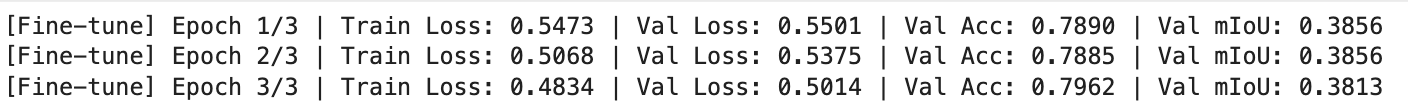

In [38]:
torch.save(
    model.state_dict(),
    "/Users/gabrielcustodioguzman/Desktop/Adleo/finetuned_unet_model.pth"
)

print("Finetuned model saved successfully.")


Finetuned model saved successfully.


#### Step 2.4: Run Inference and Generate Segmentation Predictions

After fine-tuning your UNet model, you will now evaluate it on the test dataset.

In this step, you will:

- Switch the model to evaluation mode

- Run inference using torch.no_grad()

- Generate and save segmentation predictions

- print overall accuracy and MIoU


> **Note**:
> This procedure for inference differs than the approach one would use for
> making maps. **In what way do you think this differs?**


In [39]:
def do_prediction(test_loader, model, num_classes, device, save_dir):
    save_dir = Path(save_dir)
    save_dir_hard = save_dir / "HardScore"
    os.makedirs(save_dir_hard, exist_ok=True)

    model = model.to(device)
    model.eval()

    evaluator = Evaluator(num_class=num_classes)
    evaluator.reset()

    print("--------- Start Inference (Prediction on Test dataset) -----------")

    with torch.no_grad():
        for images, labels, img_paths in test_loader:
            images = images.to(device)
            labels = labels.to(device).long()

            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)

            preds = torch.argmax(probs, dim=1)

            evaluator.add_batch(labels.cpu().numpy(), preds.cpu().numpy())

            for i in range(preds.shape[0]):
                src_path = img_paths[i]
                pred_np = preds[i].cpu().numpy().astype(np.uint8)

                with rasterio.open(src_path) as src:
                    profile = src.profile.copy()

                profile.update(
                    count=1,
                    dtype=rasterio.uint8,
                    height=pred_np.shape[0],
                    width=pred_np.shape[1]
                )

                out_name = Path(src_path).stem + "_pred.tif"
                out_path = save_dir_hard / out_name

                with rasterio.open(out_path, "w", **profile) as dst:
                    dst.write(pred_np, 1)

                print(f"Saved: {out_path}")

    overall_acc = evaluator.Pixel_Accuracy()
    miou = evaluator.Mean_Intersection_over_Union()

    print(f"Overall Pixel Accuracy: {overall_acc:.4f}")
    print(f"Mean IoU (mIoU):        {miou:.4f}")
    print("--------------------- Inference Finished ---------------------")

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_path = "/Users/gabrielcustodioguzman/Desktop/Adleo/finetuned_unet_model.pth"

model.load_state_dict(torch.load(model_path, map_location=device))

model = model.to(device)

print("Loaded fine-tuned model.")

save_dir = "/Users/gabrielcustodioguzman/Desktop/Adleo/prediction_results"

Loaded fine-tuned model.


In [41]:
do_prediction(
    test_loader=test_loader,
    model=model,
    num_classes=2,
    device=device,
    save_dir=save_dir
)

--------- Start Inference (Prediction on Test dataset) -----------


ValueError: not enough values to unpack (expected 3, got 2)

#### Step 2.5: Plot a set of image, label, and prediction.

In [42]:
pred_dir = Path(save_dir) / "HardScore"

images, labels, img_paths = next(iter(test_loader))

idx = 0

image = images[idx].permute(1, 2, 0).numpy()
label = labels[idx].numpy()

pred_path = pred_dir / (Path(img_paths[idx]).stem + "_pred.tif")

with rasterio.open(pred_path) as src:
    pred = src.read(1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image[:, :, :3])
plt.title("Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(label, cmap="gray")
plt.title("True Label")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred, cmap="gray")
plt.title("Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()


ValueError: not enough values to unpack (expected 3, got 2)

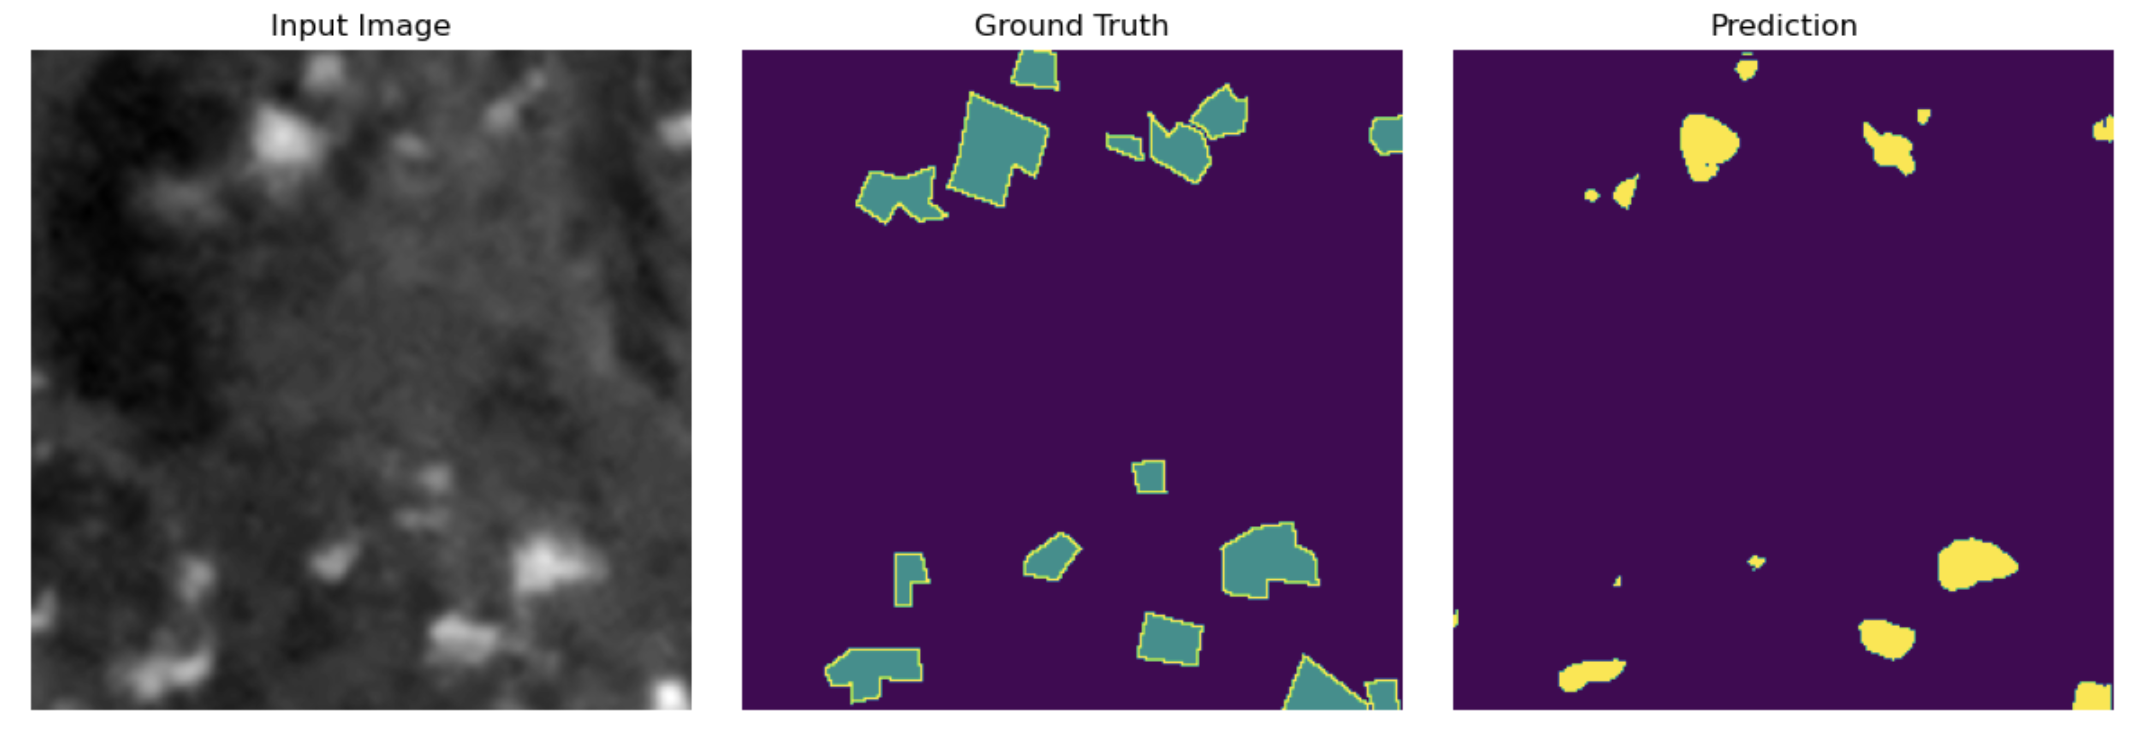